<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Unemployed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

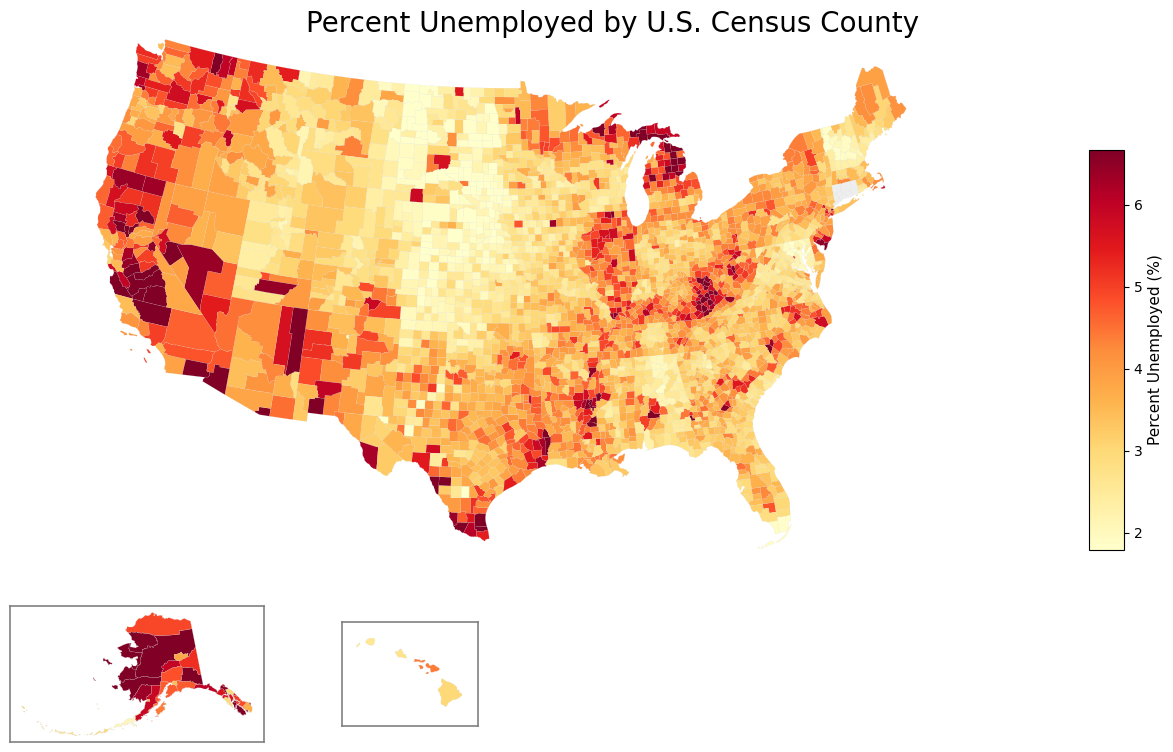

In [1]:
# Run once
# !pip install geopandas pandas matplotlib numpy openpyxl

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# Read data in excel file using pandas
file = "/content/2025 County Health Rankings Data - v4.xlsx"

chr_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

# Keep the important information
employment_df = chr_data[
    [
        "FIPS",
        "State",
        "County",
        "# Unemployed",
        "% Unemployed"
    ]
].copy()

# Keep only county rows, while not removing missing unemployment values
employment_df = employment_df[employment_df["County"].notna()].copy()

# Clean FIPS and unemployment column
employment_df["FIPS"] = (
    employment_df["FIPS"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

employment_df["% Unemployed"] = pd.to_numeric(
    employment_df["% Unemployed"],
    errors="coerce"
)

# Load county shapefile from Census
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

# Make sure coordinates are latitude/longitude
counties = counties.to_crs(epsg=4326)

# Merge unemployment data with county map
merged = counties.merge(
    employment_df,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Color scale
unemployment_values = merged["% Unemployed"].dropna()
vmin = unemployment_values.quantile(0.02)
vmax = unemployment_values.quantile(0.98)

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Main Lower 48 map
ax_main = fig.add_axes([0.03, 0.23, 0.78, 0.70])

lower48_proj.plot(
    column="% Unemployed",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.08,
    vmin=vmin,
    vmax=vmax,
    ax=ax_main,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.08
    }
)

ax_main.axis("off")

# Alaska inset box
ax_ak = fig.add_axes([0.05, 0.02, 0.22, 0.17])
ax_ak.set_facecolor("white")

alaska_proj.plot(
    column="% Unemployed",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_ak,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.12
    }
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.05
y_buffer = (maxy - miny) * 0.05

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Hawaii inset box
ax_hi = fig.add_axes([0.30, 0.04, 0.11, 0.13])
ax_hi.set_facecolor("white")

hawaii_proj.plot(
    column="% Unemployed",
    cmap="YlOrRd",
    legend=False,
    edgecolor="lightgray",
    linewidth=0.12,
    vmin=vmin,
    vmax=vmax,
    ax=ax_hi,
    missing_kwds={
        "color": "#eeeeee",
        "edgecolor": "lightgray",
        "linewidth": 0.12
    }
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("gray")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Colorbar
ax_cbar = fig.add_axes([0.84, 0.26, 0.025, 0.50])

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=vmin, vmax=vmax)
)
sm._A = []

cbar = fig.colorbar(sm, cax=ax_cbar)
cbar.set_label("Percent Unemployed (%)", fontsize=11)

# Title
fig.suptitle(
    "Percent Unemployed by U.S. Census County",
    fontsize=20,
    y=0.935
)

plt.show()